In [10]:
# 0. 라이브러리 불러오기
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

In [3]:
# 파일 업로드 하기

from google.colab import files
uploaded = files.upload()

Saving x_processed.npy to x_processed.npy


In [4]:
# 1. 데이터 불러오기

# csv->npy로 수정
# x_raw = np.load('X_rank3_tensor.npy')
y_raw = np.load('y_labels.npy')

# x_raw.shape

In [18]:
print(y_raw[:10], y_raw.shape)

['ESTP' 'ESTP' 'ESTP' 'ESTP' 'ESTP' 'ESTP' 'ESTP' 'ESTP' 'ESTP' 'ESTP'] (1765,)


In [5]:
# 전처리가 완료된 x_data
x_data = np.load('x_processed.npy')

x_data.shape

(1765, 60, 11)

## 1) 4개의 독립 binary 모델

In [19]:
# 3. y 라벨링

# mbti를 4축으로 분리하는 함수 정의
def mbti_to_axis(y_mbti):
  n = len(y_mbti)

  y_ei = np.zeros(n, dtype=int)
  y_sn = np.zeros(n, dtype=int)
  y_ft = np.zeros(n, dtype=int)
  y_pj = np.zeros(n, dtype=int)

  for i, mbti in enumerate(y_mbti):
    y_ei[i] = 1 if mbti[0] == 'E' else 0
    y_sn[i] = 1 if mbti[1] == 'N' else 0
    y_ft[i] = 1 if mbti[2] == 'T' else 0
    y_pj[i] = 1 if mbti[3] == 'J' else 0

  return y_ei, y_sn, y_ft, y_pj

In [20]:
y_ei, y_sn, y_ft, y_pj = mbti_to_axis(y_raw)

In [30]:
# 4. 데이터셋 분리

# x축도 축으로 분리를 해줘야 한다
# 하나의 x는 4개 축 라벨을 모두 가지고 있다
# 따라서 하나의 플레이리스트는 train에 들어갔으면
# ei/sn/ft/pj 4개의 라벨도 모두 train에 들어가야하므로
# x축 분리는 한번만 시행


# 학습 데이터(train+val)와 테스트 데이터(test)로 분리
idx_trainval, idx_test = train_test_split(
    np.arange(len(x_data)),
    test_size=0.2,
    random_state=42,
    stratify=y_ei     # EI 라벨 기준 stratify
)

# 학습 데이터(trainval) -> train / val 분리
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.2,   # trainval(80%) 중 20% → 전체에서 16%
    random_state=42,
    stratify=y_ei[idx_trainval]
)

# 실제로 데이터 분리
x_train = x_data[idx_train]
x_val   = x_data[idx_val]
x_test  = x_data[idx_test]

y_ei_train, y_ei_val, y_ei_test = y_ei[idx_train], y_ei[idx_val], y_ei[idx_test]
y_sn_train, y_sn_val, y_sn_test = y_sn[idx_train], y_sn[idx_val], y_sn[idx_test]
y_ft_train, y_ft_val, y_ft_test = y_ft[idx_train], y_ft[idx_val], y_ft[idx_test]
y_pj_train, y_pj_val, y_pj_test = y_pj[idx_train], y_pj[idx_val], y_pj[idx_test]


In [35]:
# 5. 모델 설정
def build_binary_cnn():
  model = Sequential([
      Conv1D(32, kernel_size=3, activation='relu', padding='same'),
      MaxPooling1D(pool_size=2),
      Conv1D(64, kernel_size=3, activation='relu', padding='same'),
      MaxPooling1D(pool_size=2),

      Flatten(),

      Dense(32,activation='relu'),
      Dropout(0.5), # 0.2 -> 0.5로 수정함
      Dense(1,activation='sigmoid') # 이진 분류이므로
  ])

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return model


# early_stopping 정의
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)


In [32]:
from sklearn import model_selection
# early_stopping 미적용

# 각각 모델을 따로 정의해야 내용이 덮어쓰지 않음
model_ei = build_binary_cnn()
model_sn = build_binary_cnn()
model_ft = build_binary_cnn()
model_pj = build_binary_cnn()
# E/I
history_ei = model_ei.fit(
    x_train, y_ei_train,
    validation_data=(x_val, y_ei_val),
    epochs=300,
    batch_size=32,
    verbose=1
)

# S/N
history_sn = model_sn.fit(
    x_train, y_sn_train,
    validation_data=(x_val, y_sn_val),
    epochs=300,
    batch_size=32,
    verbose=1
)

# F/T
history_ft = model_ft.fit(
    x_train, y_ft_train,
    validation_data=(x_val, y_ft_val),
    epochs=300,
    batch_size=32,
    verbose=1
)

# P/J
history_pj = model_pj.fit(
    x_train, y_pj_train,
    validation_data=(x_val, y_pj_val),
    epochs=300,
    batch_size=32,
    verbose=1
)

# 나중에 한꺼번에 보기 좋도록
histories = {
    "EI": history_ei,
    "SN": history_sn,
    "FT": history_ft,
    "PJ": history_pj
}

Epoch 1/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.5859 - loss: 0.6984 - val_accuracy: 0.7385 - val_loss: 0.5686
Epoch 2/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7579 - loss: 0.5359 - val_accuracy: 0.7703 - val_loss: 0.5022
Epoch 3/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7719 - loss: 0.5057 - val_accuracy: 0.7774 - val_loss: 0.4869
Epoch 4/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8027 - loss: 0.4530 - val_accuracy: 0.7633 - val_loss: 0.5163
Epoch 5/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8017 - loss: 0.4350 - val_accuracy: 0.7774 - val_loss: 0.4715
Epoch 6/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8460 - loss: 0.3662 - val_accuracy: 0.7880 - val_loss: 0.4438
Epoch 7/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8716 - loss: 0.3351 - val_accuracy: 0.7774 - val_loss: 0.4565
Epoch 8/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8657 - loss: 0.3135 - val_accuracy: 0.7880 - 

KeyboardInterrupt: 

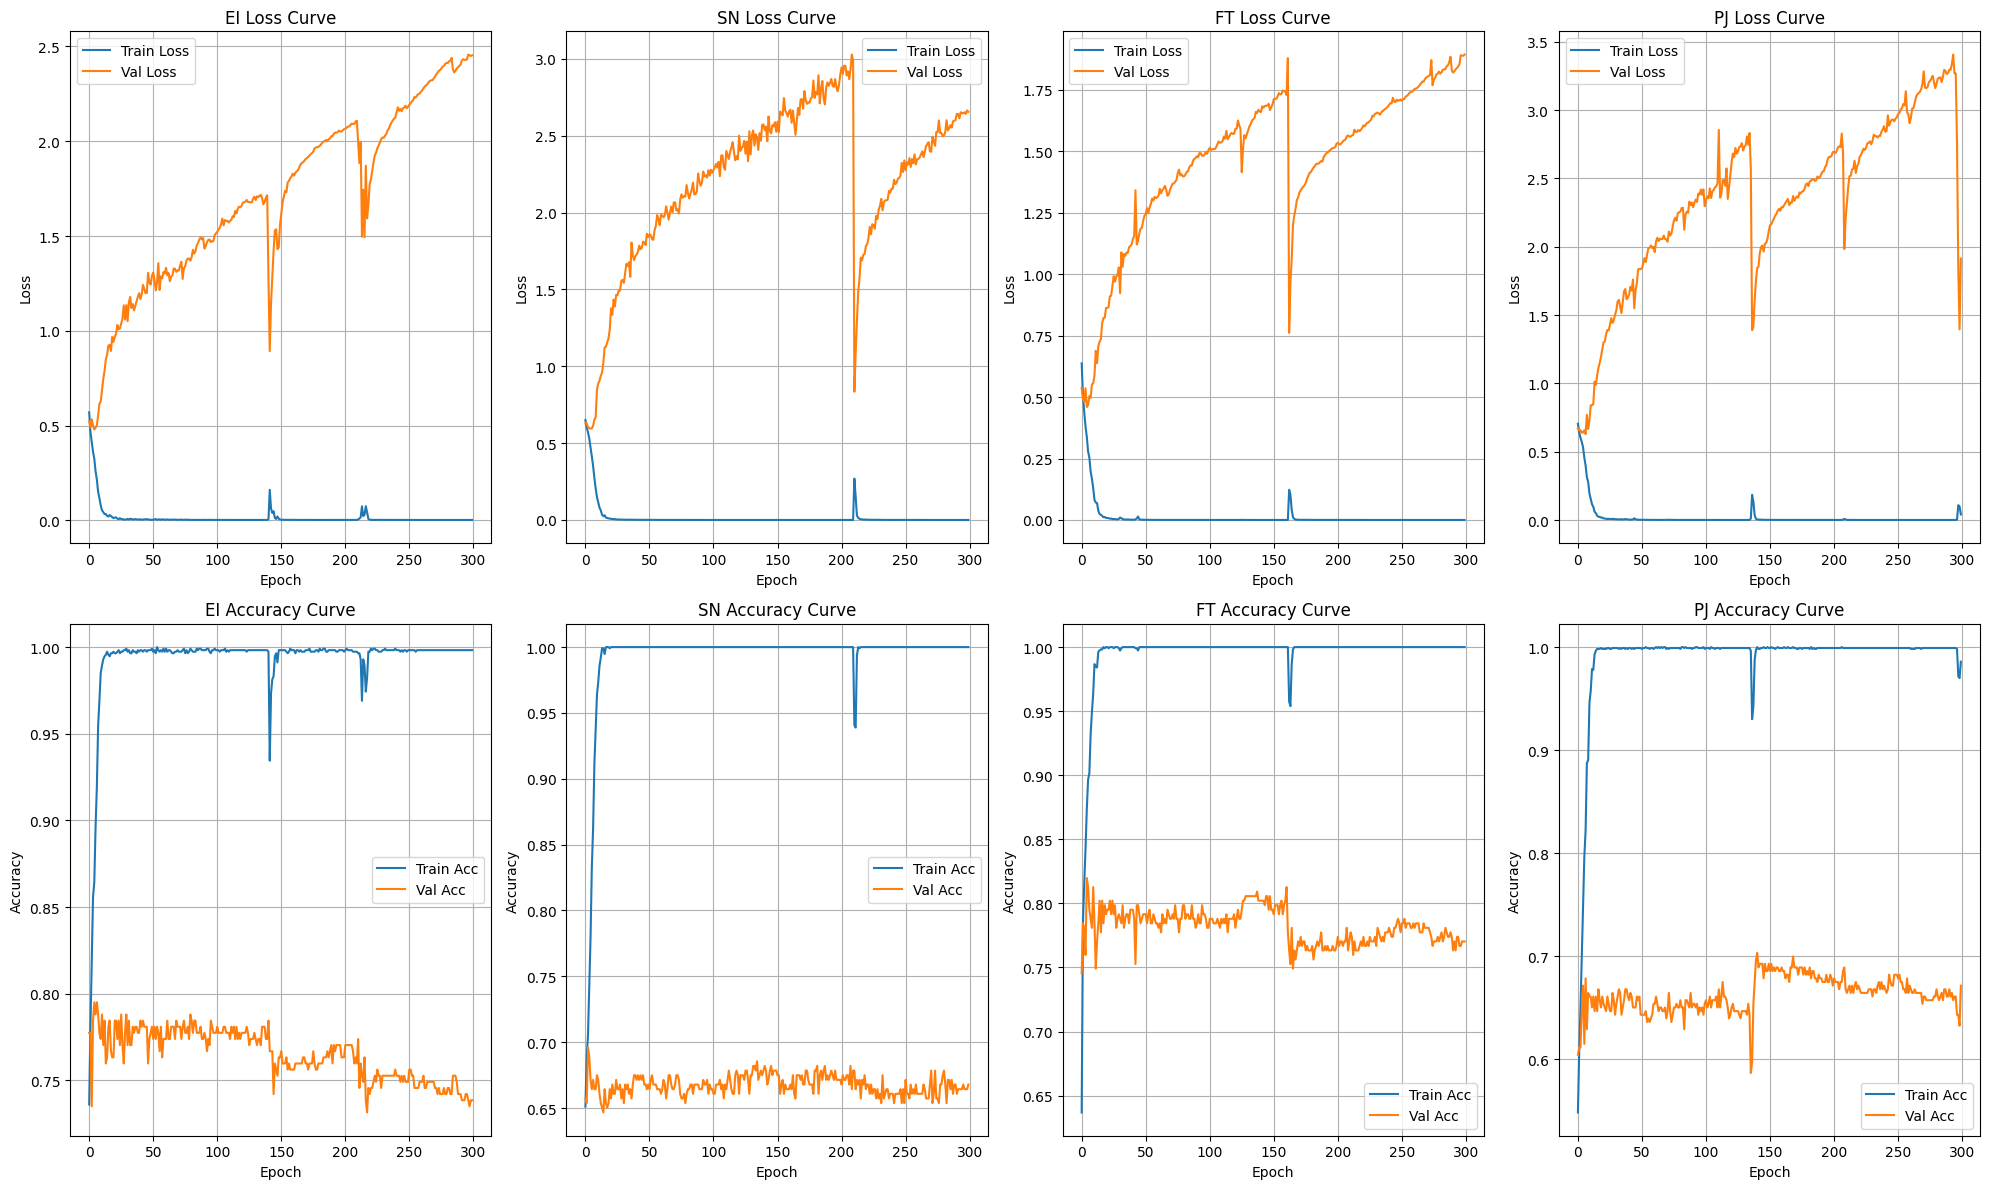

In [26]:
import matplotlib.pyplot as plt

axes_names = ["EI", "SN", "FT", "PJ"]

plt.figure(figsize=(20, 12))

# ----------------------
# 1) LOSS CURVES (상단 4개)
# ----------------------
for i, axis in enumerate(axes_names):
    history = histories[axis]

    plt.subplot(2, 4, i+1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{axis} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

# ----------------------
# 2) ACCURACY CURVES (하단 4개)
# ----------------------
for i, axis in enumerate(axes_names):
    history = histories[axis]

    plt.subplot(2, 4, i+5)  # 아래 줄
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{axis} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# early_stopping 적용

# 각각 모델을 따로 정의해야 내용이 덮어쓰지 않음
model2_ei = build_binary_cnn()
model2_sn = build_binary_cnn()
model2_ft = build_binary_cnn()
model2_pj = build_binary_cnn()


history2_ei = model2_ei.fit(
    x_train, y_ei_train,
    validation_data=(x_val, y_ei_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history2_sn = model2_sn.fit(
    x_train, y_sn_train,
    validation_data=(x_val, y_sn_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history2_ft = model2_ft.fit(
    x_train, y_ft_train,
    validation_data=(x_val, y_ft_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history2_pj = model2_pj.fit(
    x_train, y_pj_train,
    validation_data=(x_val, y_pj_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

histories2 = {
    "EI": history2_ei,
    "SN": history2_sn,
    "FT": history2_ft,
    "PJ": history2_pj
}

Epoch 1/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.5866 - loss: 0.6760 - val_accuracy: 0.7385 - val_loss: 0.5623
Epoch 2/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7606 - loss: 0.5597 - val_accuracy: 0.7739 - val_loss: 0.5040
Epoch 3/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8066 - loss: 0.4827 - val_accuracy: 0.7986 - val_loss: 0.4925
Epoch 4/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7877 - loss: 0.4964 - val_accuracy: 0.7880 - val_loss: 0.4889
Epoch 5/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7993 - loss: 0.4595 - val_accuracy: 0.7809 - val_loss: 0.4825
Epoch 6/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8150 - loss: 0.4131 - val_accuracy: 0.7845 - val_loss: 0.4768
Epoch 7/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8573 - loss: 0.3449 - val_accuracy: 0.8021 - val_loss: 0.4677
Epoch 8/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8580 - loss: 0.3348 - val_accuracy: 0.8057 - 

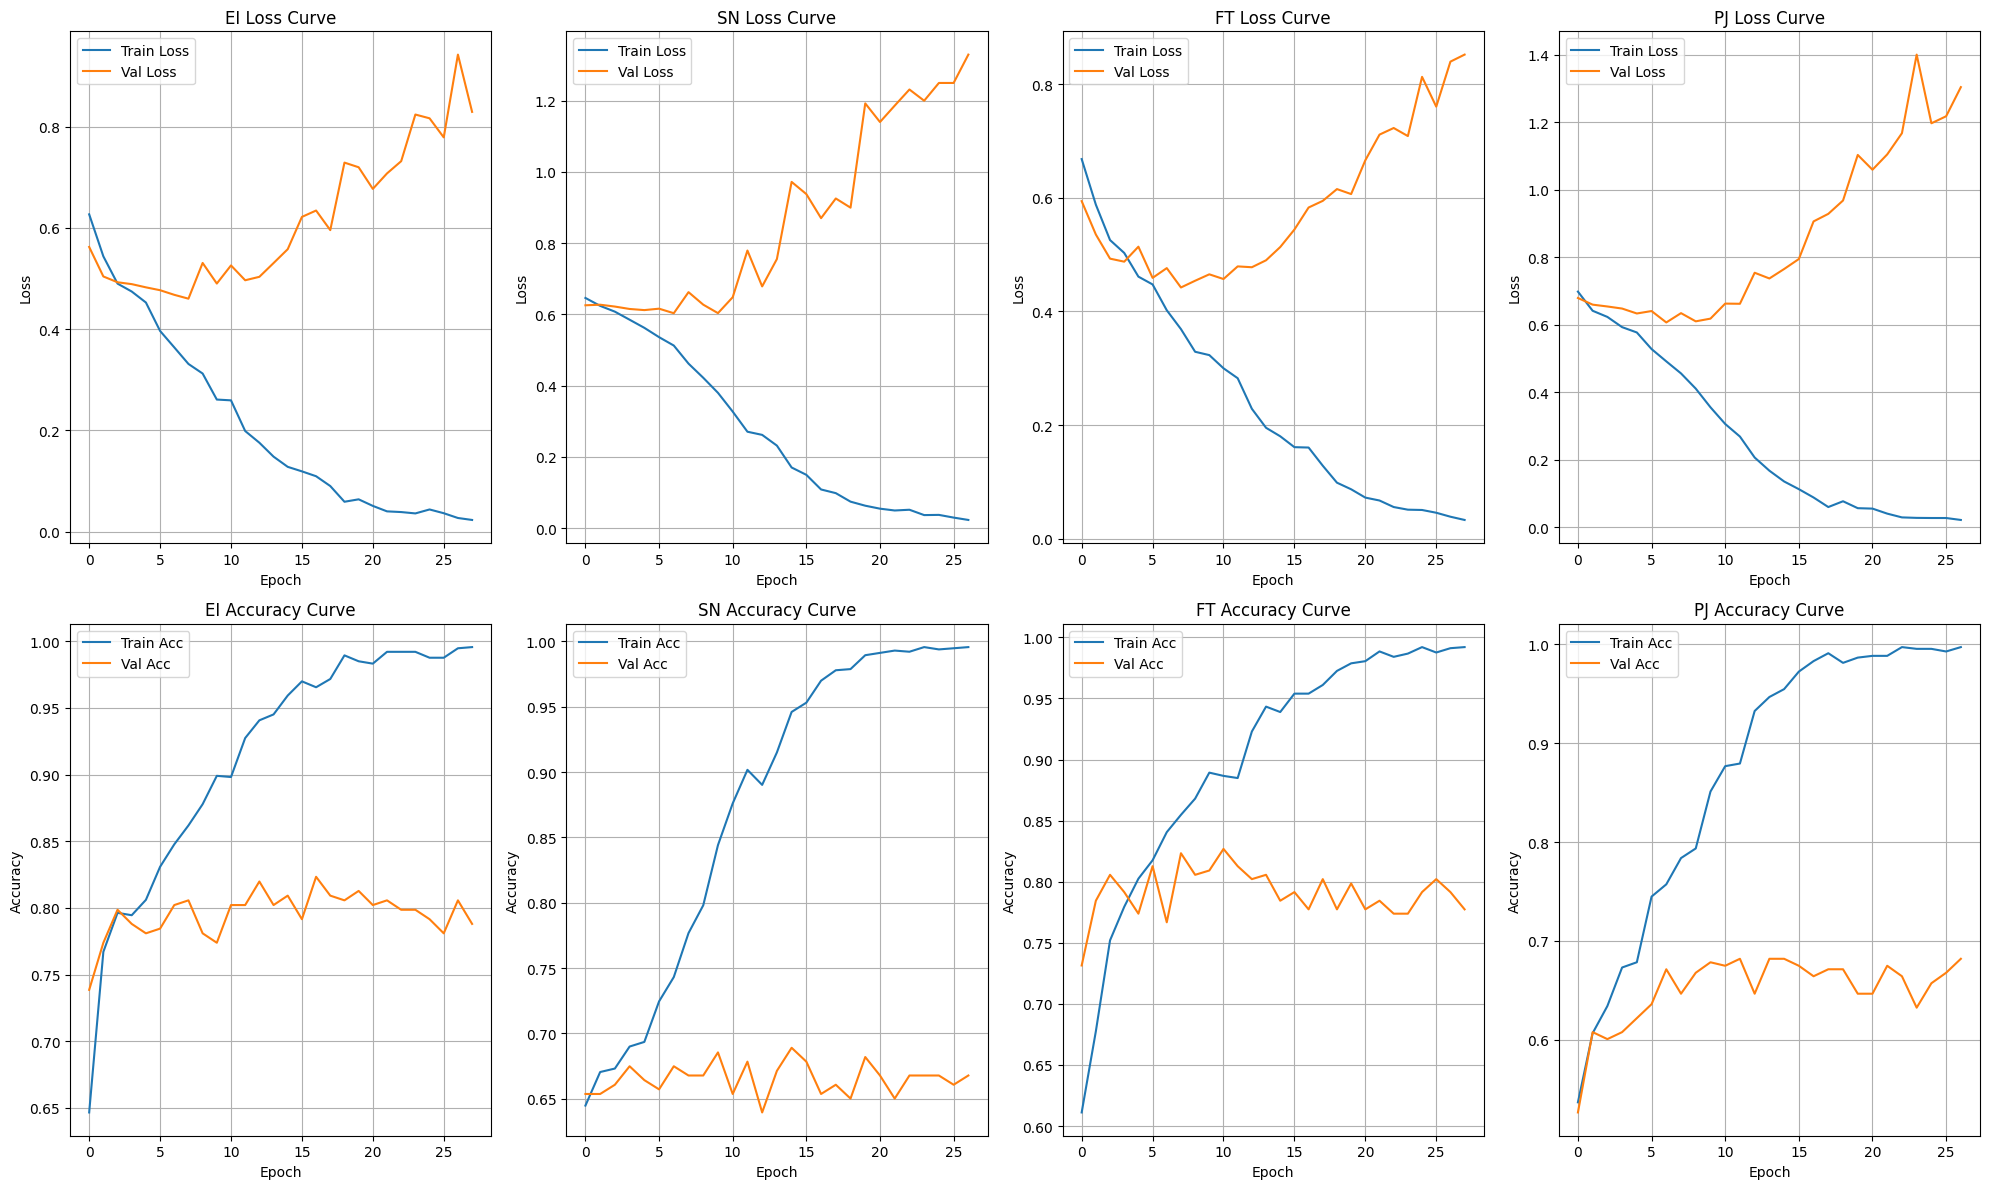

In [37]:
import matplotlib.pyplot as plt

axes_names = ["EI", "SN", "FT", "PJ"]

plt.figure(figsize=(20, 12))

# ----------------------
# 1) LOSS CURVES (상단 4개)
# ----------------------
for i, axis in enumerate(axes_names):
    history = histories2[axis]  # ★ early stopping 적용된 history 사용

    plt.subplot(2, 4, i+1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{axis} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

# ----------------------
# 2) ACCURACY CURVES (하단 4개)
# ----------------------
for i, axis in enumerate(axes_names):
    history = histories2[axis]  # ★ 여기도 histories2로 변경

    plt.subplot(2, 4, i+5)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{axis} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# L2 정규화 적용한 모델
from tensorflow.keras.regularizers import l2

def build_binary_cnn_l2():
  model = Sequential([
      Conv1D(32, kernel_size=3, activation='relu', padding='same',
             kernel_regularizer=l2(0.001)),
      MaxPooling1D(2),

      Conv1D(64, kernel_size=3, activation='relu', padding='same',
             kernel_regularizer=l2(0.001)),
      MaxPooling1D(2),

      Flatten(),

      Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
      Dropout(0.5),

      Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))
  ])

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model


In [39]:
# l2 적용시

# 각각 모델을 따로 정의해야 내용이 덮어쓰지 않음
model3_ei = build_binary_cnn_l2()
model3_sn = build_binary_cnn_l2()
model3_ft = build_binary_cnn_l2()
model3_pj = build_binary_cnn_l2()


history3_ei = model3_ei.fit(
    x_train, y_ei_train,
    validation_data=(x_val, y_ei_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history3_sn = model3_sn.fit(
    x_train, y_sn_train,
    validation_data=(x_val, y_sn_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history3_ft = model3_ft.fit(
    x_train, y_ft_train,
    validation_data=(x_val, y_ft_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

history3_pj = model3_pj.fit(
    x_train, y_pj_train,
    validation_data=(x_val, y_pj_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

histories3 = {
    "EI": history3_ei,
    "SN": history3_sn,
    "FT": history3_ft,
    "PJ": history3_pj
}

Epoch 1/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.6074 - loss: 0.7708 - val_accuracy: 0.7703 - val_loss: 0.6457
Epoch 2/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7707 - loss: 0.6426 - val_accuracy: 0.7880 - val_loss: 0.6025
Epoch 3/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7905 - loss: 0.5839 - val_accuracy: 0.7986 - val_loss: 0.5747
Epoch 4/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7958 - loss: 0.5812 - val_accuracy: 0.7915 - val_loss: 0.5649
Epoch 5/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7925 - loss: 0.5600 - val_accuracy: 0.8163 - val_loss: 0.5424
Epoch 6/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8170 - loss: 0.5452 - val_accuracy: 0.8092 - val_loss: 0.5477
Epoch 7/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8396 - loss: 0.4846 - val_accuracy: 0.8127 - val_loss: 0.5243
Epoch 8/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8450 - loss: 0.4660 - val_accuracy: 0.8198 - 

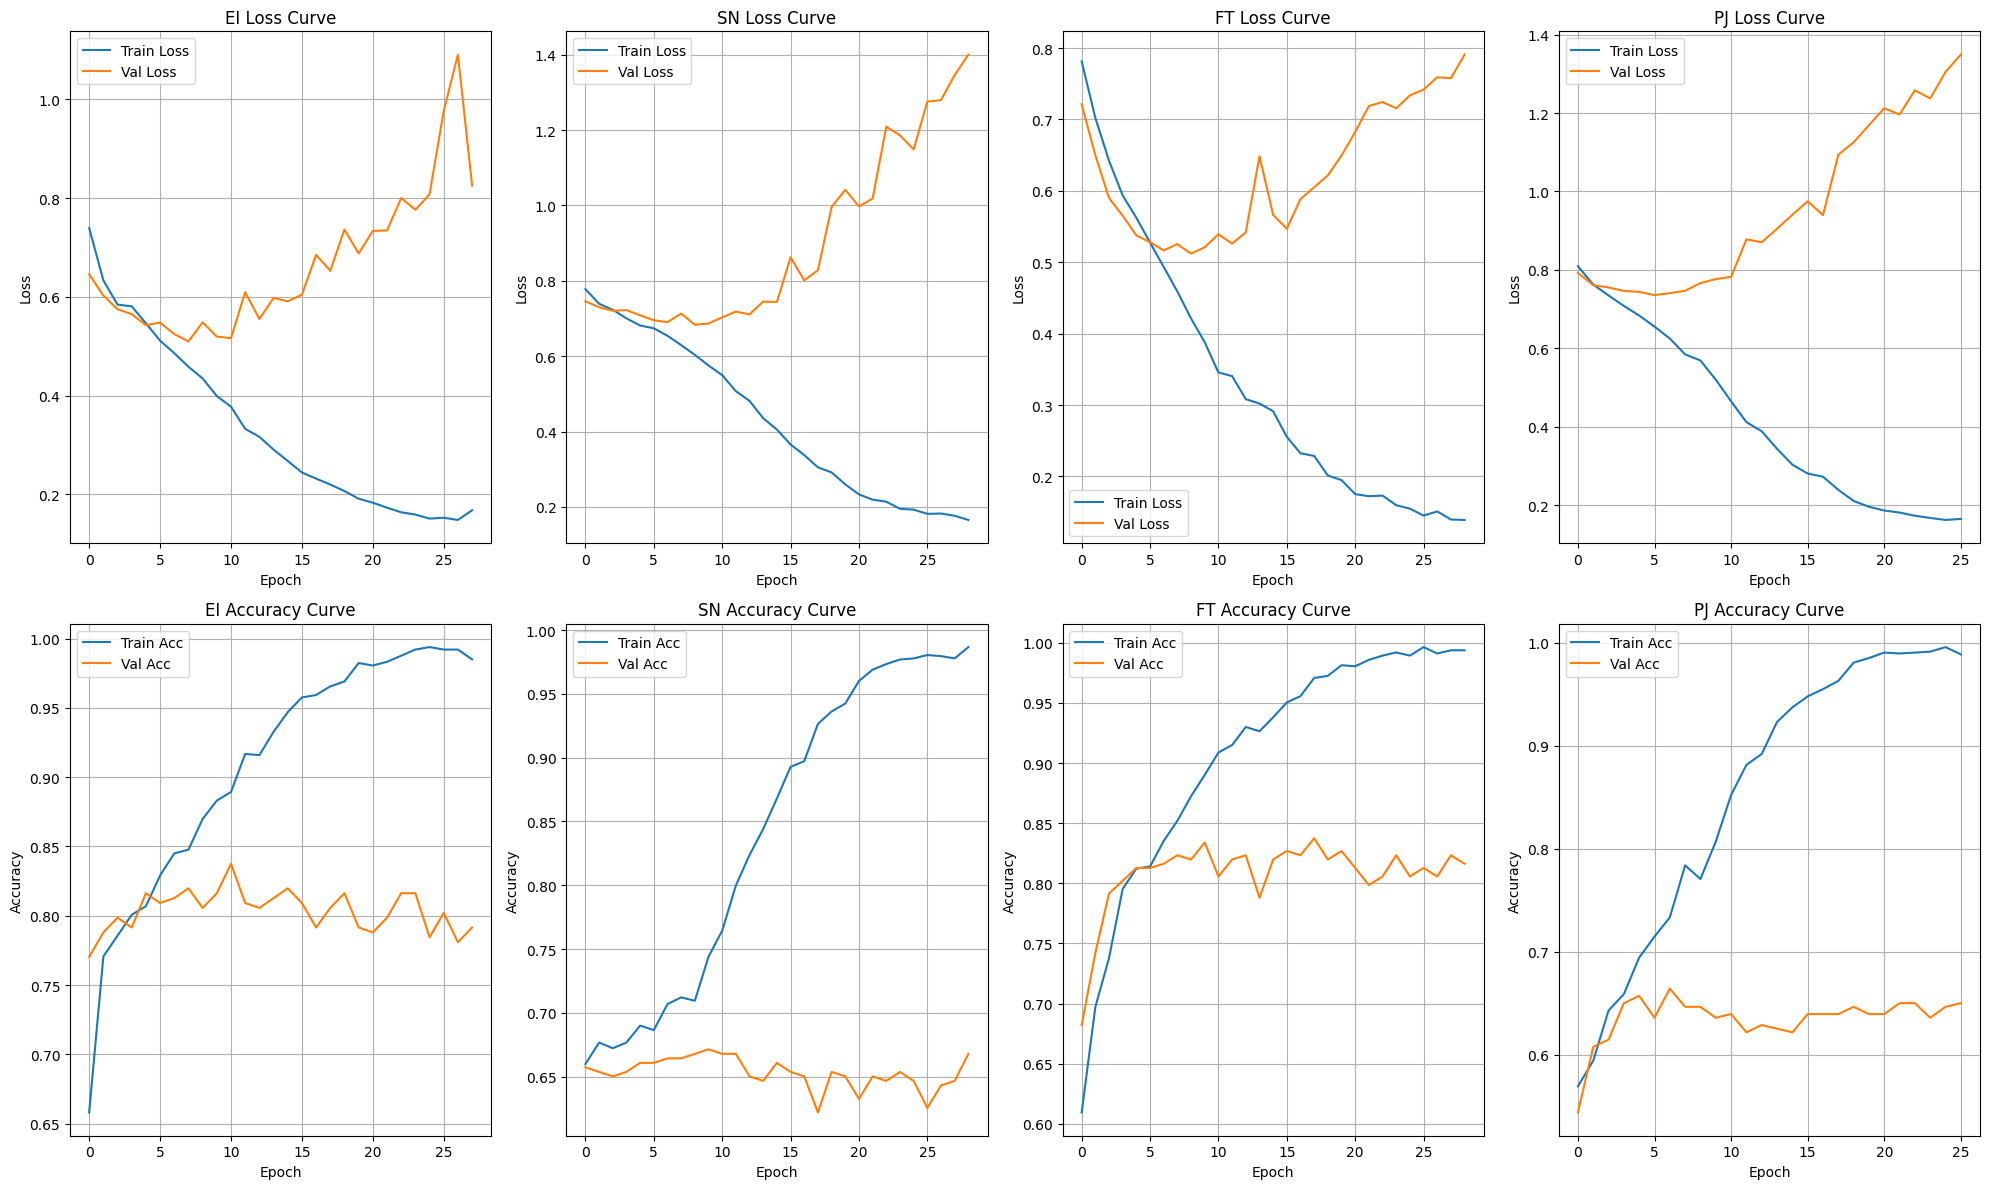

In [40]:
import matplotlib.pyplot as plt

axes_names = ["EI", "SN", "FT", "PJ"]

plt.figure(figsize=(20, 12))

# ----------------------
# 1) LOSS CURVES (상단 4개)
# ----------------------
for i, axis in enumerate(axes_names):
    history = histories3[axis]     # ★ histories → histories3 로 수정

    plt.subplot(2, 4, i+1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{axis} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

# ----------------------
# 2) ACCURACY CURVES (하단 4개)
# ----------------------
for i, axis in enumerate(axes_names):
    history = histories3[axis]     # ★ histories → histories3 로 수정

    plt.subplot(2, 4, i+5)  # 아래 줄
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{axis} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

In [43]:
### full mbti 테스트 ###
pred_ei = (model3_ei.predict(x_test) > 0.5).astype(int).flatten()
pred_sn = (model3_sn.predict(x_test) > 0.5).astype(int).flatten()
pred_ft = (model3_ft.predict(x_test) > 0.5).astype(int).flatten()
pred_pj = (model3_pj.predict(x_test) > 0.5).astype(int).flatten()

def combine_mbti(ei, sn, ft, pj):
    return (
        ("E" if ei==1 else "I") +
        ("N" if sn==1 else "S") +
        ("T" if ft==1 else "F") +
        ("J" if pj==1 else "P")
    )

pred_mbti = [
    combine_mbti(ei, sn, ft, pj)
    for ei, sn, ft, pj in zip(pred_ei, pred_sn, pred_ft, pred_pj)
]

full_accuracy = (pred_mbti == y_raw[idx_test]).mean()
print("Full MBTI Accuracy:", full_accuracy)

def partial_accuracy(pred_list, true_list):
    total = 0
    for p, t in zip(pred_list, true_list):
        total += sum([p[i] == t[i] for i in range(4)]) / 4
    return total / len(pred_list)

print("Partial Accuracy:", partial_accuracy(pred_mbti, y_raw[idx_test]))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Full MBTI Accuracy: 0.32011331444759206
Partial Accuracy: 0.7273371104815864


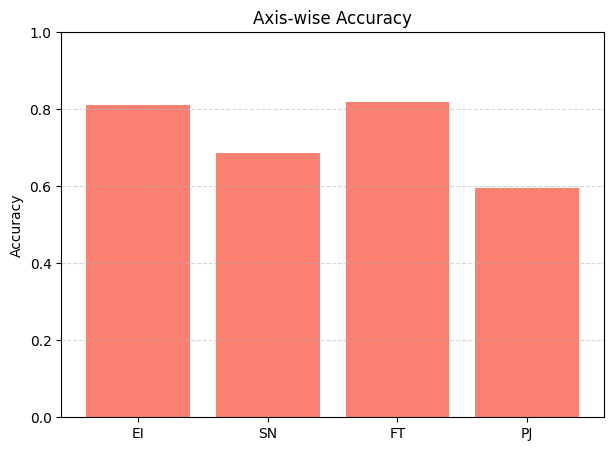

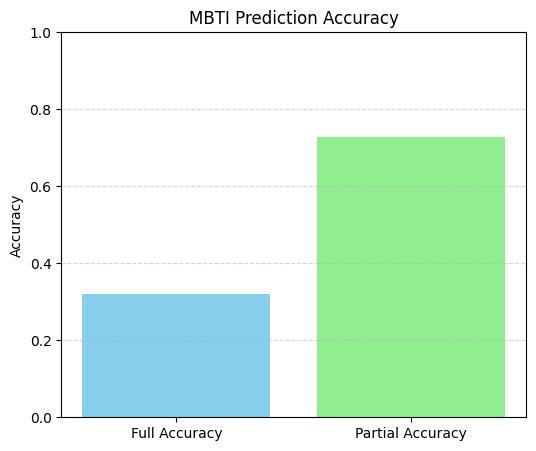

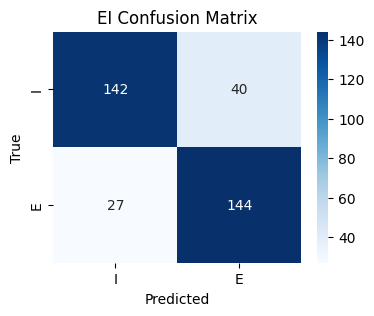

In [47]:
import matplotlib.pyplot as plt

# 각 축별로 정확도
axis_acc = {
    "EI": (pred_ei == y_ei_test).mean(),
    "SN": (pred_sn == y_sn_test).mean(),
    "FT": (pred_ft == y_ft_test).mean(),
    "PJ": (pred_pj == y_pj_test).mean(),
}

plt.figure(figsize=(7,5))
plt.bar(axis_acc.keys(), axis_acc.values(), color='salmon')
plt.ylim(0,1)
plt.title("Axis-wise Accuracy")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 전체 mbti를 다 맞췄을 때랑 부분적으로 맞춘거 정확도
full_acc = full_accuracy
partial_acc = partial_accuracy(pred_mbti, y_raw[idx_test])

plt.figure(figsize=(6,5))
plt.bar(['Full Accuracy','Partial Accuracy'], [full_acc, partial_acc], color=['skyblue','lightgreen'])
plt.ylim(0,1)
plt.title("MBTI Prediction Accuracy")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



## 2) 하나의 CNN에서 4개의 출력을 동시에 내는 Multitask

In [8]:
# 3. y라벨링
import numpy as np

def mbti_to_multitask_label(y_mbti):
    labels = []
    for mbti in y_mbti:
        ei = 1 if mbti[0] == 'E' else 0
        sn = 1 if mbti[1] == 'N' else 0
        ft = 1 if mbti[2] == 'T' else 0
        pj = 1 if mbti[3] == 'J' else 0
        labels.append([ei, sn, ft, pj])
    return np.array(labels)

y_multi = mbti_to_multitask_label(y_raw)

y_multi.shape

(1765, 4)

In [11]:
# 4. 데이터셋 분리

# trainval과 test로 분리
idx_trainval, idx_test = train_test_split(
    np.arange(len(x_data)),
    test_size=0.2,
    random_state=42,
    stratify=y_multi[:, 0]   # EI 축 기준 stratify
)

# trainval -> train/val 분리

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_multi[idx_trainval, 0]   # EI 기준 stratify
)


# 실제 데이터 분리 수행
x_train = x_data[idx_train]
x_val   = x_data[idx_val]
x_test  = x_data[idx_test]

y_train = y_multi[idx_train]
y_val   = y_multi[idx_val]
y_test  = y_multi[idx_test]

In [16]:
# 5. 모델 설정

from tensorflow.keras.regularizers import l2

def build_multitask_cnn_l2():
  model = Sequential([
      Conv1D(32, kernel_size= 3, activation='relu', padding='same',
             kernel_regularizer=l2(1e-4),
             input_shape=(60,11)),
      MaxPooling1D(pool_size=2),

      Conv1D(64, kernel_size=3, activation='relu', padding='same',
             kernel_regularizer=l2(1e-4)),
      MaxPooling1D(pool_size=2),

      Flatten(),

      Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
      Dropout(0.5),

      Dense(4, activation='sigmoid') # multi-label binary

  ])

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['binary_accuracy'])
  return model


# early_stopping 정의 (동일)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [17]:
model_mt = build_multitask_cnn_l2()

history_mt = model_mt.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - binary_accuracy: 0.5632 - loss: 0.7059 - val_binary_accuracy: 0.6608 - val_loss: 0.6595
Epoch 2/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6221 - loss: 0.6662 - val_binary_accuracy: 0.6661 - val_loss: 0.6417
Epoch 3/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6360 - loss: 0.6433 - val_binary_accuracy: 0.6776 - val_loss: 0.6311
Epoch 4/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6584 - loss: 0.6351 - val_binary_accuracy: 0.6829 - val_loss: 0.6139
Epoch 5/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6729 - loss: 0.6107 - val_binary_accuracy: 0.6935 - val_loss: 0.6020
Epoch 6/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6862 - loss: 0.5965 - val_binary_accuracy: 0.6820 - val_loss: 0.6018
Epoch 7/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7043 - loss: 0.5789 - val_binary_accuracy: 0.6935 - val_loss: 0.5918
Epoch 8/300


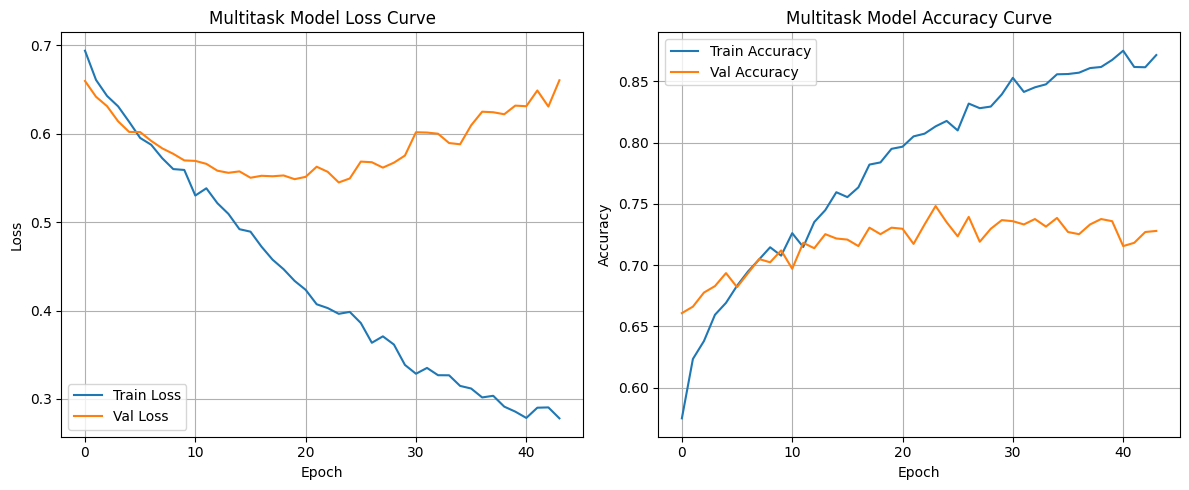

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# ----------------------
# 1) LOSS CURVE
# ----------------------
plt.subplot(1, 2, 1)
plt.plot(history_mt.history['loss'], label='Train Loss')
plt.plot(history_mt.history['val_loss'], label='Val Loss')
plt.title("Multitask Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# ----------------------
# 2) ACCURACY CURVE (binary_accuracy)
# ----------------------
plt.subplot(1, 2, 2)
plt.plot(history_mt.history['binary_accuracy'], label='Train Accuracy')
plt.plot(history_mt.history['val_binary_accuracy'], label='Val Accuracy')
plt.title("Multitask Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# 테스트 데이터

# 1) 모델 전체 수준 테스트 - multitast 성능 개괄
model_mt.evaluate(x_test, y_test)

# 2) 각 축별로 테스트
pred = (model_mt.predict(x_test) > 0.5).astype(int)

ei_acc = (pred[:,0] == y_test[:,0]).mean()
sn_acc = (pred[:,1] == y_test[:,1]).mean()
ft_acc = (pred[:,2] == y_test[:,2]).mean()
pj_acc = (pred[:,3] == y_test[:,3]).mean()

# 3) 전체 mbti 정확도
def combine_mbti(ei, sn, ft, pj):
    return (
        ("E" if ei==1 else "I") +
        ("N" if sn==1 else "S") +
        ("T" if ft==1 else "F") +
        ("J" if pj==1 else "P")
    )

pred_mbti = [combine_mbti(*row) for row in pred]

full_acc = (np.array(pred_mbti) == y_raw[idx_test]).mean()

# 4)
def partial_accuracy(pred_list, true_list):
    total = 0
    for p, t in zip(pred_list, true_list):
        total += sum([p[i] == t[i] for i in range(4)]) / 4
    return total / len(pred_list)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7030 - loss: 0.5897 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


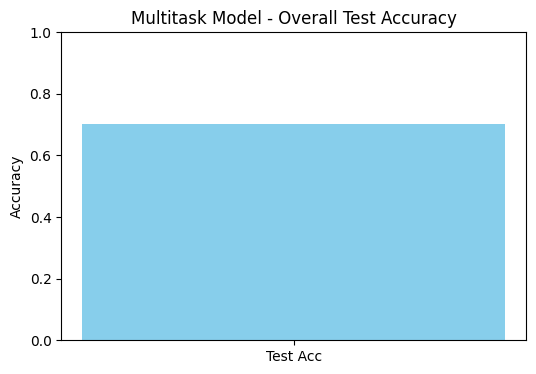

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


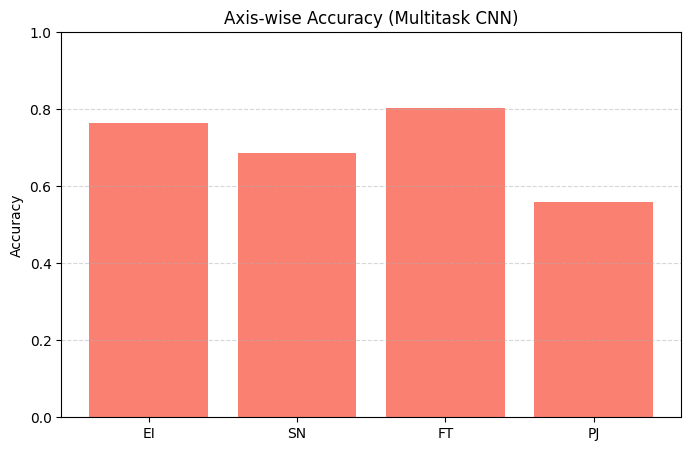

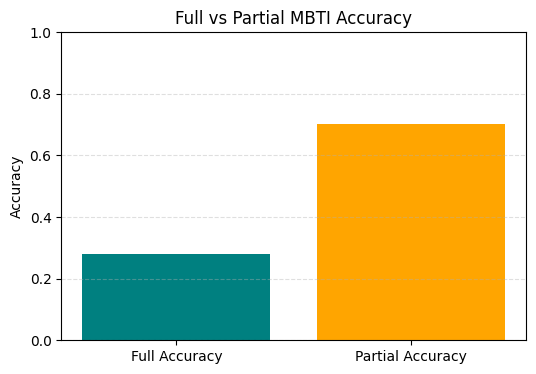

In [24]:
# 1) 전체 모델 평가 후 시각화
test_loss, test_acc = model_mt.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(6,4))
plt.bar(["Test Acc"], [test_acc], color="skyblue")
plt.ylim(0,1)
plt.title("Multitask Model - Overall Test Accuracy")
plt.ylabel("Accuracy")
plt.show()


# 2) 축별로 테스트 후 시각화
pred = (model_mt.predict(x_test) > 0.5).astype(int)

ei_acc = (pred[:,0] == y_test[:,0]).mean()
sn_acc = (pred[:,1] == y_test[:,1]).mean()
ft_acc = (pred[:,2] == y_test[:,2]).mean()
pj_acc = (pred[:,3] == y_test[:,3]).mean()

axis_names = ["EI", "SN", "FT", "PJ"]
axis_acc = [ei_acc, sn_acc, ft_acc, pj_acc]

plt.figure(figsize=(8,5))
plt.bar(axis_names, axis_acc, color="salmon")
plt.ylim(0,1)
plt.title("Axis-wise Accuracy (Multitask CNN)")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# 3) full mbti
def combine_mbti_vec(pred_row):
    return (
        ("E" if pred_row[0]==1 else "I") +
        ("N" if pred_row[1]==1 else "S") +
        ("T" if pred_row[2]==1 else "F") +
        ("J" if pred_row[3]==1 else "P")
    )

pred_mbti = [combine_mbti_vec(row) for row in pred]

true_mbti = [combine_mbti_vec(row) for row in y_test]

full_acc = (np.array(pred_mbti) == np.array(true_mbti)).mean()
full_acc

# partial
def partial_accuracy(pred_list, true_list):
    total = 0
    for p, t in zip(pred_list, true_list):
        total += sum([p[i] == t[i] for i in range(4)]) / 4
    return total / len(pred_list)

pacc = partial_accuracy(pred_mbti, true_mbti)

plt.figure(figsize=(6,4))
plt.bar(["Full Accuracy", "Partial Accuracy"], [full_acc, pacc],
        color=["teal","orange"])
plt.ylim(0,1)
plt.title("Full vs Partial MBTI Accuracy")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()